In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import numpy as np
import sklearn

In [46]:
def extract_require_statements(parquet_file_path):
    df = pd.read_parquet(parquet_file_path)
    df_filtered = df[df['failure_invariant'].notna()].copy()
    df_filtered['failure_invariant_str'] = df_filtered['failure_invariant'].astype(str).str.lower().str.strip().str.replace(' ', ' ', regex=False)
    revert_rows = df_filtered[df_filtered['failure_invariant_str'].str.contains('require', na=False)]
    revert_rows.to_parquet("Unique_invariants", index=False)

    return revert_rows['failure_invariant_str'].tolist()


In [43]:
import re

def extract_conditions(parquet_file_path):
    cleaned_require_statements = []
    require_statements = extract_require_statements(parquet_file_path)
    
    for stmt in require_statements:
        stmt = stmt.strip()

        # Extract content inside require(...)
        match = re.match(r'^require\((.*)\);?$', stmt)
        if match:
            inner = match.group(1).strip()
            condition = extract_before_top_level_comma(inner)
            cleaned_require_statements.append(condition)

    return cleaned_require_statements

def extract_before_top_level_comma(s):
    depth = 0
    for i, char in enumerate(s):
        if char == '(':
            depth += 1
        elif char == ')':
            depth -= 1
        elif char == ',' and depth == 0:
            return s[:i].strip()
    return s.strip()  # No comma found outside nested parentheses


In [44]:
import ast
from typing import List

def parse_snippets_to_asts(snippets: List[str]) -> List[ast.AST]:
    """
    Parses a list of Solidity code snippets directly into Python ASTs.
    No transformations are done — this assumes the syntax is parseable by Python.
    """
    asts = []
    for code in snippets:
        try:
            node = ast.parse(code)
            asts.append(node)
        except SyntaxError as e:
            print(f"Skipping snippet due to parse error: {code}")
            continue
    return asts


In [47]:
file_path = "../datasets/analysis/MS_All_20000.parquet"
conditions = extract_conditions(file_path)
conditions_unique = list(set(conditions))
require_statements = extract_require_statements(file_path)
require_unique = list(set(require_statements))


In [ ]:
res = pd.read_parquet("../datasets/analysis/Unique_require.parquet")
print(len(res))
print(res.head(4))

5770
                                                hash  \
0  0x66aa08944b89e9d0522e170a93bcc49bf55e096de5b7...   
1  0xaed8d5d49199c6fe4e5b18504e1cb9f4d5e269a6fbba...   
2  0xbcf2380ecbba548c58f37b38ce21c2fbb2134bf1be98...   
3  0xd512b4768e440111e7d42bdd75eaa44261212da6aaf1...   

                                failure_reason  block_number  \
0       ERC20: transfer amount exceeds balance      21846879   
1                       Trading not active yet      20529028   
2  UniswapV2Router: INSUFFICIENT_OUTPUT_AMOUNT      20703990   
3       ERC20: transfer amount exceeds balance      21115761   

                                 from_address  \
0  0x1a510709aefaca7102ac3b54ada64762b8d15721   
1  0xe5cfe71f783d3bff5736f4be1bc44cf58b812e62   
2  0x3229378620b8318f3012fb32d63363e5d5b22947   
3  0x6c4898242ec8efe57cd079b435a11cb56fa28804   

                                   to_address  \
0  0xbce44616d96ba1659fac008ed3d9f171f67d254e   
1  0xc418ff17c8690f4020b3abb055879b562affb255   


# DBSCAN

- Jaccard Distance, Cosine Distance, AST edit distance with TF-IDF vectors


## Jaccard Distance

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances


def dbscan_cluster_jaccard(invariants, eps=0.5, min_samples=5, metric = 'cosine'):
    vectorizer = CountVectorizer(binary=True)
    X = vectorizer.fit_transform(invariants).toarray()  # dense array
    distance_matrix = pairwise_distances(X, metric='jaccard')

    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    db.fit(distance_matrix)
    cluster_dict = {}
    for label, invariant in zip(db.labels_, invariants):
        if label == -1:
            continue
        if label not in cluster_dict:
            cluster_dict[label] = []
        cluster_dict[label].append(invariant)
    
    return cluster_dict


In [13]:
labels = dbscan_cluster_jaccard(conditions_unique, eps=0.5, min_samples=3)
statement_count = 0
cluster_counter = 0

for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    cluster_counter += 1
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(require_unique))
print(statement_count)
print(cluster_counter)

C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Cluster 0:
  block.timestamp < endtime
  block.timestamp <= _deadline
  block.timestamp >= _auction.endtime
  block.timestamp <= gooduntil
  _claimtime >= block.timestamp
  expiration == 0 || block.timestamp <= expiration
  block.timestamp <= deadline
  deadline >= block.timestamp
  expires > block.timestamp


Cluster 1:
  uniswapv2pair != from && uniswapv2pair != to
  _cantx[from] || _cantx[to]
  _isexcludedfromfee[from] || _isexcludedfromfee[to]
  !bots[from] && !bots[to]
  from == _owner || to == _owner
  tradingenabled || _isexcludedfromfees[from] || _isexcludedfromfees[to]
  isfeeexempt[from] || isfeeexempt[to]
  _isexcludedfromtaxes[from] || _isexcludedfromtaxes[to]
  isexcludedfromfees[from] || isexcludedfromfees[to]
  bexcludedfromtax[from] || bexcludedfromtax[to]
  excludedfromtax[from] || excludedfromtax[to]
  !blackwomans[from] && !blackwomans[to]
  isfreebird[from] || isfreebird[to]
  _isexcludedfromfees[from] || _isexcludedfromfees[to]
  _isexcludedfromtax[from] || _isexcl

## Cosine Distance

In [14]:
def dbscan_cluster_cosine(invariants, eps=0.5, min_samples=5, metric = 'cosine'):
    """
    DBSCAN with cosine 
    """
    vectorizer = TfidfVectorizer()
    invariant_vectors = vectorizer.fit_transform(invariants)
    db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    db.fit(invariant_vectors)
    cluster_dict = {}
    for label, invariant in zip(db.labels_, invariants):
        if label == -1:
            continue
        if label not in cluster_dict:
            cluster_dict[label] = []
        cluster_dict[label].append(invariant)
    
    return cluster_dict


In [18]:
labels = dbscan_cluster_cosine(require_unique, eps=0.4, min_samples=2)
statement_count = 0
cluster_counter = 0

for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    cluster_counter += 1
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(require_unique))
print(statement_count)
print(cluster_counter)

Cluster 0:
  require(tradingenabled, "trading is paused");
  require(!paused(), "pausable: paused");
  require(!paused(), "erc20pausable: token transfer while paused");
  require(!paused);
  require(!paused() || hasexception(_msgsender()), "pausable: paused (and no exception)");
  require(!_paused, "pausable: paused");
  require(!_paused);


Cluster 1:
  require(recoveredaddress == owner, 'mapletoken:invalid_signature');
  require(recoveredaddress != address(0) && recoveredaddress == owner, 'uniswapv2: invalid_signature');


Cluster 2:
  require( _isexcludedfromfee[from] || _isexcludedfromfee[to], "trading is not yet open" );
  require( _isexcludedfromfee[from] || _isexcludedfromfee[to], "trading is not open yet and you are not authorized" );
  require( _isexcludedfromfee[from] || _isexcludedfromfee[to], "taoblack: trading is not yet open" );
  require( _isexcludedfromfee[to] || _isexcludedfromfee[from], "trading not yet open" );
  require(_isexcludedfromfee[from] || _isexcludedfromfee

In [106]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import DBSCAN

def cosine_dbscan_2(invariants, eps=0.3, min_samples=3):

    db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    db.fit(invariants)

    cluster_dict = {}
    for label, invariant in zip(db.labels_, conditions_unique):
        if label == -1:
            continue
        cluster_dict.setdefault(label, []).append(invariant)

    return cluster_dict

In [104]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(conditions_unique)

In [107]:
labels = cosine_dbscan_2(embeddings, eps=0.2, min_samples=2)
statement_count = 0
cluster_counter = 0

for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    cluster_counter += 1
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(require_unique))
print(statement_count)
print(cluster_counter)

Cluster 0:
  !address.iscontract(_to)||!address.iscontract(_from)
  address(msg.sender).iscontract()&&allowedcontracts[msg.sender]||!address(msg.sender).iscontract()


Cluster 1:
  senderbalance>=amount_
  balances[_ids[i]][_from]>=_amounts[i]
  _value<=balances[_from]
  balances[_from]>=_value&&allowed[_from][msg.sender]>=_value&&_value>0
  balances[msg.sender]==0
  _balances[from]>amount
  value<=_balanceof(from)
  accountbalance>=amount
  _balances[from]>=amount
  amount<=_balances[from]
  frombalance>=amount
  previousbalancefrom>=amount
  balance>=amount
  senderbalance>=amount
  balanceof[msg.sender]>=wad
  balanceof(from)>=amountin
  balanceof(msg.sender)==0
  balances[_from]>=_value
  amount<=balances[sender]
  _amount<=balanceof(_from)
  balanceof[_from]>=_value
  wreact.balanceof(msg.sender)>=amount
  _balances[sender]>=amount
  amount<=userbalance
  _value<=balances[msg.sender]
  value<=balances[from]
  frombalancebefore>=amount
  value<=_balances[from]
  currentbalance>=amo

## Levensthein Distance

In [60]:
from sklearn.cluster import DBSCAN
import numpy as np
import Levenshtein

def dbscan_cluster_levenstein(invariants, eps=0.5, min_samples=5):
    n = len(invariants)
    distance_matrix = np.zeros((n, n))

    # Compute Levenshtein distances pairwise
    for i in range(n):
        for j in range(i + 1, n):
            dist = Levenshtein.distance(invariants[i], invariants[j])
            distance_matrix[i][j] = dist
            distance_matrix[j][i] = dist  # symmetric

    # Run DBSCAN on precomputed distance matrix
    vectorizer = TfidfVectorizer()
    invariant_vectors = vectorizer.fit_transform(invariants)
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    db.fit(distance_matrix)

    cluster_dict = {}
    for label, invariant in zip(db.labels_, invariants):
        if label == -1:
            continue  # noise
        cluster_dict.setdefault(label, []).append(invariant)

    return cluster_dict


In [72]:
labels = dbscan_cluster_levenstein(require_unique, eps=15, min_samples=4)
statement_count = 0
cluster_counter = 0

for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    cluster_counter += 1
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(require_unique))
print(statement_count)
print(cluster_counter)

Cluster 0:
  require(trading,"binofi:tradingisdisable");
  require(_tradingopen(msg.sender),"tradingnotopen");
  require(!paused);
  require(n<2**96,errormessage);
  require(launch,"notlaunched");
  require(b<=a);
  require(amount>0,"nothingtostake");
  require(balanceof[src]>=wad);
  require(starttradeblock>0);
  require(tradingactive,"tradingisnotactive.");
  require(tradingenabled,"tradingispaused");
  require(tick%tickspacing==0);
  require(tradingopen,"tradingnotopen");
  require(sub(l[from],0)==0);
  require(starttx,"notstart");
  require(haslp);
  require(_tradingenable,"tradingdisabled!");
  require(blacklist[msg.sender]==false);
  require(trading,"rexasfinance:tradingisdisable");
  require(_balances[from]>amount);
  require(hash==root,"1");
  require(balanceof[_from]>=_value);
  require(trading,"lightchainai:tradingisdisabled");
  require(allowance[src][msg.sender]>=wad);
  require(from==owner(),"tradingisnotenabled");
  require(tradingopen,"tradingnotopenyet");
  require(!isc

## AST with TF-IDF vectors
- harder than thought to change it into AST syntax

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

def dbscan_with_ast_tfidf(invariants, eps=0.5, min_samples=2):
    ast_texts = parse_snippets_to_asts(invariants)
   
    vectorizer = TfidfVectorizer()
    X_tfidf = vectorizer.fit_transform(ast_texts)
    
    distance_matrix = pairwise_distances(X_tfidf, metric='cosine')
    clustering = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed')
    clustering.fit(distance_matrix)
    cluster_dict = {}
    for label, invariant in zip(clustering.labels_, invariants):
        if label == -1:
            continue
        if label not in cluster_dict:
            cluster_dict[label] = []
        cluster_dict[label].append(invariant)

    return cluster_dict


## Run it

In [ ]:
labels = dbscan_cluster_levenstein(conditions, eps=12, min_samples=2)
statement_count = 0
for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    counter = 0
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(conditions))
print(statement_count)


Cluster 0:
  require(trading,"lightchainai:tradingisdisabled");
  require(trading,"rexasfinance:tradingisdisable");
  require(trading,"binofi:tradingisdisable");


Cluster 1:
  require(_x7w88<_e242);
  require(!_paused);
  require(!iscontract(to));
  require((z=x-y)<=x);
  require(launch);
  require(false,"isnotopen");
  require(amount>0);
  require(haslp);
  require(b<=a);
  require(!stopped);
  require(!paused);
  require(hash==root,"1");


Cluster 2:
  require(ierc20(path[path.length-1]).balanceof(to).sub(balancebefore)>=amountoutmin,'ethervistarouter:insufficient_output_amount');
  require(ierc20(path[path.length-1]).balanceof(to).sub(balancebefore)>=amountoutmin,'uniswapv2router:insufficient_output_amount');
  require(ierc20uniswap(path[path.length-1]).balanceof(to).sub(balancebefore)>=amountoutmin,'uniswapv2router:insufficient_output_amount');
  require(ierc20(path[path.length-1]).balanceof(to).sub(balancebefore)>=amountoutmin,'etherosrouter:insufficient_output_amount');


Cluste

## AST Analysis

# COCLUBERT

## PDG Analysis

# LSI AND DBSAN

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances

def lsi_transform(documents, n_components=10):
    """
    Transforms documents into LSI-reduced semantic vectors.
    """
    vectorizer = TfidfVectorizer(stop_words='english')
    X_tfidf = vectorizer.fit_transform(documents)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    normalizer = Normalizer(copy=False)
    lsi = make_pipeline(svd, normalizer)

    X_lsi = lsi.fit_transform(X_tfidf)
    return X_lsi, svd, vectorizer

def cluster_lsi_average_linkage(vectors, n_clusters=5):
    """
    Clusters LSI vectors using Agglomerative Clustering with average linkage.
    """
    dist_matrix = cosine_distances(vectors)
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
    labels = agglomerative.fit_predict(dist_matrix)
    return labels

def semantic_clustering_lsi(documents, n_components=200, n_clusters=5):
    """
    Full LSI + Average-Linkage clustering pipeline.
    """
    # Step 1: Apply LSI to the documents
    vectors, svd, vectorizer = lsi_transform(documents, n_components)

    # Step 2: Apply Average-Linkage clustering
    labels = cluster_lsi_average_linkage(vectors, n_clusters)

    # Step 3: Organize documents by cluster labels
    clustered_docs = {}
    for doc, label in zip(documents, labels):
        clustered_docs.setdefault(label, []).append(doc)

    return clustered_docs


In [23]:
labels = semantic_clustering_lsi(require_unique, n_components=100, n_clusters=30)
statement_count = 0
cluster_counter = 0

for cluster_label, statements in labels.items():
    print(f"Cluster {cluster_label}:")
    cluster_counter += 1
    for statement in statements:
        statement_count +=  1
        print(f"  {statement}")
    print("\n")
print(len(require_unique))
print(statement_count)
print(cluster_counter)

Cluster 3:
  require(tradingenabled, "trading is paused");
  if(!isfeeexempt[sender] && !isfeeexempt[recipient]){require(tradingallowed, "tradingallowed");}
  require(uniswapv2pair != from && uniswapv2pair != to, "trading is not active.");
  require(tradingopen, "trading is not open");
  require(tradehasbegun, "trading not yet launched");
  require( _excludedfromfees[from] || _excludedfromfees[to], "trading is not active." );
  require(tradingenabled || _isexcludedfromfees[from] || _isexcludedfromfees[to], "trading not yet enabled!");
  require(from == owner(), "token: this account cannot send tokens until trading is enabled");
  require(_isexcludedfromfees[from] || _isexcludedfromfees[to], "trading is not active.");
  require( transfertaxexempt[from] || transfertaxexempt[to], "_transfer:: trading is not active." );
  require(isfreebird[from] || isfreebird[to], "trading is not active.");
  require(tradeenabled, "trading not enabled");
  require(stakeobj.active, "peakstaking: not active

C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\cluster\_agglomerative.py:588: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


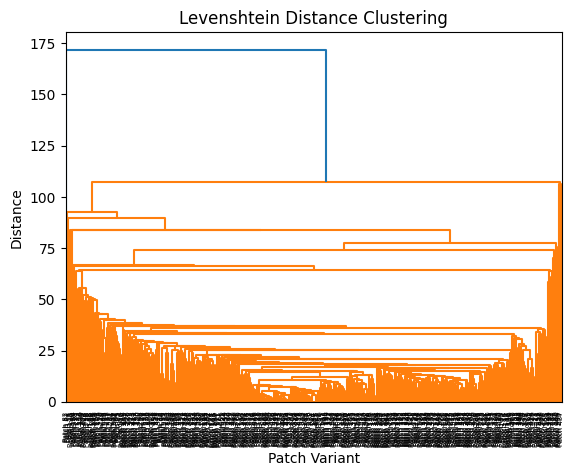

C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\cluster\hierarchy.py:2818: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


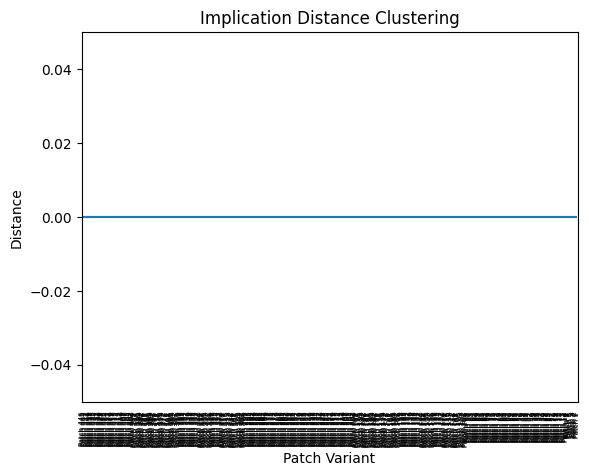

In [ ]:
import numpy as np
from z3 import *
from Levenshtein import distance as levenshtein_distance
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Helper to normalize invariants
def normalize(inv):
    return inv.replace(" ", "").replace("==", "=")

# For Levenshtein distance
def set_to_symbol_string(invariants):
    symbol_map = {}
    result = ""
    next_char = ord("A")
    for inv in invariants:
        inv = normalize(inv)
        if inv not in symbol_map:
            symbol_map[inv] = chr(next_char)
            next_char += 1
        result += symbol_map[inv]
    return result

def compute_lev_matrix(data):
    n = len(data)
    matrix = np.zeros((n, n))
    strings = [set_to_symbol_string(d) for d in data]
    for i in range(n):
        for j in range(n):
            matrix[i][j] = levenshtein_distance(strings[i], strings[j])
    return matrix

# Implication using Z3
def to_z3_expr(s):
    s = normalize(s)
    try:
        if ">=" in s:
            lhs, rhs = s.split(">=")
            return parse_smt2_string(f"(assert (>= {lhs} {rhs}))")[0]
        elif ">" in s:
            lhs, rhs = s.split(">")
            return parse_smt2_string(f"(assert (> {lhs} {rhs}))")[0]
        elif "=" in s:
            lhs, rhs = s.split("=")
            return parse_smt2_string(f"(assert (= {lhs} {rhs}))")[0]
        else:
            return None
    except:
        return None

def implication_distance(setA, setB):
    A = [to_z3_expr(x) for x in setA if to_z3_expr(x)]
    B = [to_z3_expr(x) for x in setB if to_z3_expr(x)]
    count = 0
    for b in B:
        s = Solver()
        s.add(Not(Implies(And(*A), b)))
        if s.check() == sat:
            count += 1
    return count

def compute_imp_matrix(data):
    n = len(data)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] = implication_distance(data[i], data[j])
    return matrix

def plot_dendrogram(matrix, labels, title):
    condensed = matrix[np.triu_indices(len(labels), 1)]
    Z = linkage(condensed, method='average')  # UPGMA
    dendrogram(Z, labels=labels)
    plt.title(title)
    plt.xlabel("Patch Variant")
    plt.ylabel("Distance")
    plt.show()

# Run clustering with Levenshtein
lev_matrix = compute_lev_matrix(conditions_unique)
plot_dendrogram(lev_matrix, [f"Patch {i}" for i in range(len(conditions_unique))], "Levenshtein Distance Clustering")

# Run clustering with Z3 Implication
imp_matrix = compute_imp_matrix(conditions_unique)
plot_dendrogram(imp_matrix, [f"Patch {i}" for i in range(len(conditions_unique))], "Implication Distance Clustering")


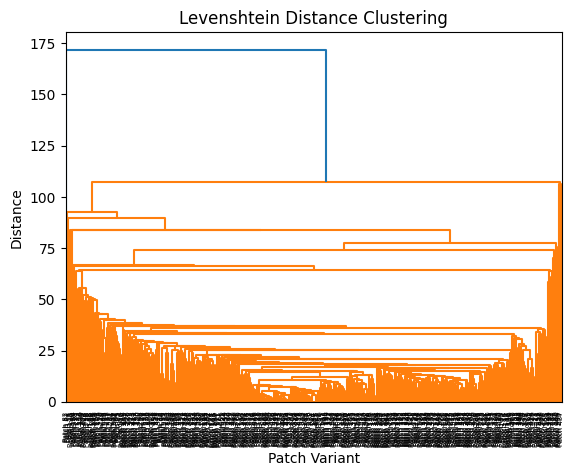

C:\Users\Melis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\cluster\hierarchy.py:2818: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


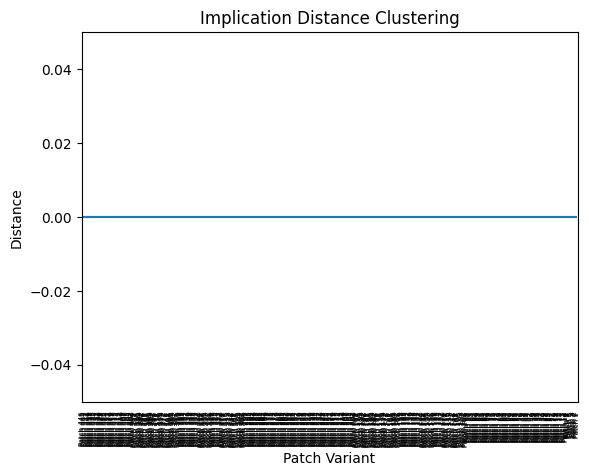

In [ ]:
from z3 import *
import numpy as np
from Levenshtein import distance as levenshtein_distance
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Helper to normalize invariants
def normalize(inv):
    return inv.replace(" ", "").replace("==", "=")

# For Levenshtein distance (as it seems to be fine)
def set_to_symbol_string(invariants):
    symbol_map = {}
    result = ""
    next_char = ord("A")
    for inv in invariants:
        inv = normalize(inv)
        if inv not in symbol_map:
            symbol_map[inv] = chr(next_char)
            next_char += 1
        result += symbol_map[inv]
    return result

# Define function for parsing the Solidity conditions
def parse_condition(cond):
    cond = normalize(cond)
    if "==" in cond:
        lhs, rhs = cond.split("==")
        return lhs == rhs  # Using Python's equality check for simplicity
    elif ">=" in cond:
        lhs, rhs = cond.split(">=")
        return lhs >= rhs  # Using Python's greater-than-or-equal check
    elif ">" in cond:
        lhs, rhs = cond.split(">")
        return lhs > rhs  # Using Python's greater-than check
    elif "<=" in cond:
        lhs, rhs = cond.split("<=")
        return lhs <= rhs  # Using Python's less-than-or-equal check
    elif "<" in cond:
        lhs, rhs = cond.split("<")
        return lhs < rhs  # Using Python's less-than check
    elif "=" in cond:
        lhs, rhs = cond.split("=")
        return lhs == rhs  # Using Python's equality check
    else:
        return None

def implication_distance(setA, setB):
    A = [parse_condition(x) for x in setA if parse_condition(x)]
    B = [parse_condition(x) for x in setB if parse_condition(x)]
    
    count = 0
    for b in B:
        s = Solver()
        s.add(Not(Implies(And(*A), b)))
        if s.check() == sat:
            count += 1
    return count

def compute_imp_matrix(data):
    n = len(data)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            matrix[i][j] = implication_distance(data[i], data[j])
    return matrix

def plot_dendrogram(matrix, labels, title):
    condensed = matrix[np.triu_indices(len(labels), 1)]
    Z = linkage(condensed, method='average')  # UPGMA
    dendrogram(Z, labels=labels)
    plt.title(title)
    plt.xlabel("Patch Variant")
    plt.ylabel("Distance")
    plt.show()

# Example usage
# Run clustering with Levenshtein
lev_matrix = compute_lev_matrix(conditions_unique)
plot_dendrogram(lev_matrix, [f"Patch {i}" for i in range(len(conditions_unique))], "Levenshtein Distance Clustering")

# Run clustering with Z3 Implication
imp_matrix = compute_imp_matrix(conditions_unique)
plot_dendrogram(imp_matrix, [f"Patch {i}" for i in range(len(conditions_unique))], "Implication Distance Clustering")


In [37]:
from z3 import *
import re

# Step 1: Infer variable names from an invariant string
def extract_vars(expr):
    return sorted(set(re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', expr)))

# Step 2: Attempt to declare a variable with a guessed type
def declare_vars(var_names):
    var_map = {}
    for var in var_names:
        if var not in var_map:
            # Default to Int, but could be smarter
            var_map[var] = Int(var)
    return var_map

# Step 3: Safe parsing using eval with Z3 environment
def parse_invariant(inv_str, var_map):
    try:
        return eval(inv_str, {}, var_map)
    except Exception as e:
        print(f"Error parsing: '{inv_str}': {e}")
        return None

# Step 4: Build distance matrix with implication check
def compute_patchwork_distances(inv_list):
    all_vars = set()
    for inv in inv_list:
        all_vars.update(extract_vars(inv))
    var_map = declare_vars(all_vars)

    parsed = [parse_invariant(inv, var_map) for inv in inv_list]

    n = len(parsed)
    distance_matrix = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i == j or parsed[i] is None or parsed[j] is None:
                continue
            s = Solver()
            s.add(And(parsed[i], Not(parsed[j])))
            result = s.check()
            if result == unsat:
                distance_matrix[i][j] = 0  # A implies B
            else:
                distance_matrix[i][j] = 1  # A does not imply B (basic metric)

    return distance_matrix

matrix = compute_patchwork_distances(conditions_unique)

for statement in matrix:
    print(statement)

Error parsing: 'amount <= ierc20(token).balanceof(address(this)).mul(gettokenlimitmaxmultiplier(token)).div(precision)': 'ArithRef' object is not callable
Error parsing: '!iscontract(to)': invalid syntax (<string>, line 1)
Error parsing: 'nestingstarted[tokenid] == 0 || nestingtransfer == 2': invalid syntax (<string>, line 1)
Error parsing: 'msg.value >= usdctoeth(pair.selltotalfee())': 'ArithRef' object has no attribute 'value'
Error parsing: 'block.timestamp >= staker.stakingtime + lock_time': 'ArithRef' object has no attribute 'timestamp'
Error parsing: '!mintingcomplete': invalid syntax (<string>, line 1)
Error parsing: 'block.timestamp < endtime': 'ArithRef' object has no attribute 'timestamp'
Error parsing: 'uniswapv2pair != from && uniswapv2pair != to': invalid syntax (<string>, line 1)
Error parsing: '!ispaused': invalid syntax (<string>, line 1)
Error parsing: 'islaunched || isexcludedfromlimits[from] || isexcludedfromlimits[to]': invalid syntax (<string>, line 1)
Error parsin

Z3Exception: Value cannot be converted into a Z3 Boolean value